# Store Sales Time Series Forecasting - Exploratory Data Analysis

This notebook provides a comprehensive exploration of the store sales dataset, examining patterns, trends, and relationships that will inform our forecasting approach.

## Dataset Overview
- **Sales Data**: Daily sales by store and product family
- **Store Information**: Location, type, and cluster data
- **External Factors**: Oil prices, holidays, and promotional activities
- **Time Period**: 2013-2017 (approximately 4.5 years)


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Initial Inspection

In [3]:
# Load all datasets
print("Loading datasets...")

# Main sales data
sales_df = pd.read_csv('../data/main_df.csv', parse_dates=['date'])
print(f"Sales data shape: {sales_df.shape}")

# Store information
stores_df = pd.read_csv('../data/stores.csv')
print(f"Stores data shape: {stores_df.shape}")

# Oil prices
oil_df = pd.read_csv('../data/oil.csv', parse_dates=['date'])
print(f"Oil data shape: {oil_df.shape}")

# Holidays and events
holidays_df = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
print(f"Holidays data shape: {holidays_df.shape}")

# Transactions (if available)
try:
    transactions_df = pd.read_csv('../data/transactions.csv', parse_dates=['date'])
    print(f"Transactions data shape: {transactions_df.shape}")
except:
    print("Transactions data not available or empty")
    transactions_df = None

print("\nAll datasets loaded successfully!")

Loading datasets...
Sales data shape: (3000888, 6)
Stores data shape: (54, 5)
Oil data shape: (1218, 2)
Holidays data shape: (350, 6)
Transactions data shape: (83488, 3)

All datasets loaded successfully!


In [4]:
# Display basic information about each dataset
print("=== SALES DATA INFO ===")
print(sales_df.info())
print("\nFirst 5 rows:")
print(sales_df.head())
print("\nBasic statistics:")
print(sales_df.describe())

=== SALES DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None

First 5 rows:
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

Basic statistics:
                 id                           date     store_nbr  \
count  3.000888e+06                        3000888

In [5]:
print("=== STORES DATA INFO ===")
print(stores_df.info())
print("\nFirst 5 rows:")
print(stores_df.head())
print("\nUnique values per column:")
for col in stores_df.columns:
    print(f"{col}: {stores_df[col].nunique()} unique values")

=== STORES DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None

First 5 rows:
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

Unique values per column:
store_nbr: 54 unique values
city: 22 unique values
state: 1

In [6]:
print("=== OIL DATA INFO ===")
print(oil_df.info())
print("\nFirst 5 rows:")
print(oil_df.head())
print("\nMissing values:")
print(oil_df.isnull().sum())
print("\nBasic statistics:")
print(oil_df.describe())

=== OIL DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB
None

First 5 rows:
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20

Missing values:
date           0
dcoilwtico    43
dtype: int64

Basic statistics:
                      date   dcoilwtico
count                 1218  1175.000000
mean   2015-05-02 12:00:00    67.714366
min    2013-01-01 00:00:00    26.190000
25%    2014-03-03 06:00:00    46.405000
50%    2015-05-02 12:00:00    53.190000
75%    2016-06-30 18:00:00    95.660000
max    2017-08-31 00:00:00   110.620000
std                    NaN    25.630476


In [7]:
print("=== HOLIDAYS DATA INFO ===")
print(holidays_df.info())
print("\nFirst 5 rows:")
print(holidays_df.head())
print("\nUnique values per column:")
for col in holidays_df.select_dtypes(include=['object']).columns:
    print(f"{col}: {holidays_df[col].nunique()} unique values")
    if holidays_df[col].nunique() < 20:
        print(f"  Values: {holidays_df[col].unique()}")

=== HOLIDAYS DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB
None

First 5 rows:
        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad  

## 2. Data Quality Assessment

In [8]:
# Check for missing values across all datasets
def check_missing_values(df, name):
    print(f"\n=== MISSING VALUES IN {name.upper()} ===")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if len(missing_df) > 0:
        print(missing_df)
    else:
        print("No missing values found!")
    return missing_df

# Check all datasets
missing_sales = check_missing_values(sales_df, 'Sales')
missing_stores = check_missing_values(stores_df, 'Stores')
missing_oil = check_missing_values(oil_df, 'Oil')
missing_holidays = check_missing_values(holidays_df, 'Holidays')

if transactions_df is not None:
    missing_transactions = check_missing_values(transactions_df, 'Transactions')


=== MISSING VALUES IN SALES ===
No missing values found!

=== MISSING VALUES IN STORES ===
No missing values found!

=== MISSING VALUES IN OIL ===
            Missing Count  Missing %
dcoilwtico             43   3.530378

=== MISSING VALUES IN HOLIDAYS ===
No missing values found!

=== MISSING VALUES IN TRANSACTIONS ===
No missing values found!


In [9]:
# Check for duplicates
print("=== DUPLICATE ANALYSIS ===")
print(f"Sales data duplicates: {sales_df.duplicated().sum()}")
print(f"Stores data duplicates: {stores_df.duplicated().sum()}")
print(f"Oil data duplicates: {oil_df.duplicated().sum()}")
print(f"Holidays data duplicates: {holidays_df.duplicated().sum()}")

# Check for logical duplicates in sales data (same date, store, family)
sales_logical_dups = sales_df.duplicated(subset=['date', 'store_nbr', 'family']).sum()
print(f"\nSales logical duplicates (same date/store/family): {sales_logical_dups}")

=== DUPLICATE ANALYSIS ===
Sales data duplicates: 0
Stores data duplicates: 0
Oil data duplicates: 0
Holidays data duplicates: 0

Sales logical duplicates (same date/store/family): 0


## 3. Time Series Analysis

In [10]:
# Time range analysis
print("=== TIME RANGE ANALYSIS ===")
print(f"Sales data date range: {sales_df['date'].min()} to {sales_df['date'].max()}")
print(f"Oil data date range: {oil_df['date'].min()} to {oil_df['date'].max()}")
print(f"Holidays data date range: {holidays_df['date'].min()} to {holidays_df['date'].max()}")

# Calculate total days and check for gaps
date_range = pd.date_range(start=sales_df['date'].min(), end=sales_df['date'].max())
missing_dates = set(date_range) - set(sales_df['date'].unique())
print(f"\nTotal days in range: {len(date_range)}")
print(f"Unique dates in sales data: {sales_df['date'].nunique()}")
print(f"Missing dates: {len(missing_dates)}")

if len(missing_dates) > 0 and len(missing_dates) < 10:
    print(f"Missing dates: {sorted(missing_dates)}")

=== TIME RANGE ANALYSIS ===
Sales data date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Oil data date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Holidays data date range: 2012-03-02 00:00:00 to 2017-12-26 00:00:00

Total days in range: 1688
Unique dates in sales data: 1684
Missing dates: 4
Missing dates: [Timestamp('2013-12-25 00:00:00'), Timestamp('2014-12-25 00:00:00'), Timestamp('2015-12-25 00:00:00'), Timestamp('2016-12-25 00:00:00')]


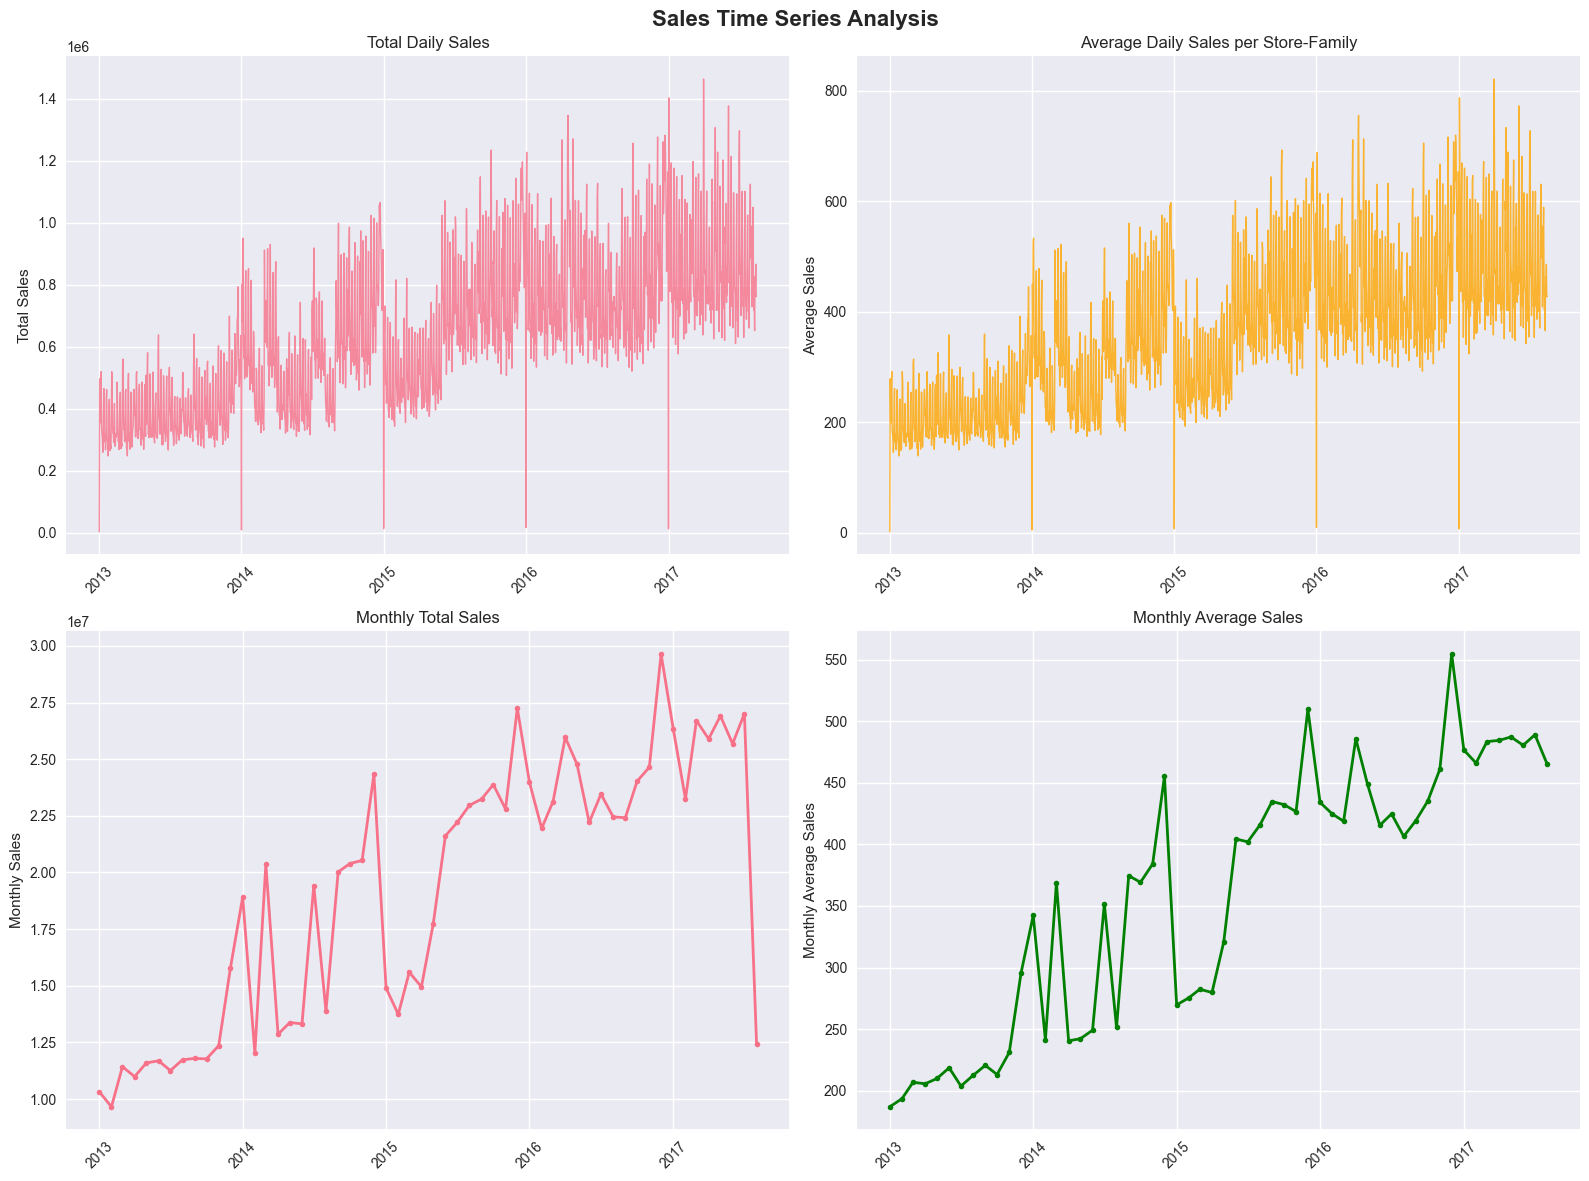


Overall sales statistics:
Total sales over period: $1,073,644,952.20
Average daily total sales: $637,556.38
Peak daily sales: $1,463,083.96 on 2017-04-01
Lowest daily sales: $2,511.62 on 2013-01-01


In [11]:
# Overall sales trend over time
daily_sales = sales_df.groupby('date')['sales'].agg(['sum', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Time Series Analysis', fontsize=16, fontweight='bold')

# Total daily sales
axes[0,0].plot(daily_sales['date'], daily_sales['sum'], linewidth=1, alpha=0.8)
axes[0,0].set_title('Total Daily Sales')
axes[0,0].set_ylabel('Total Sales')
axes[0,0].tick_params(axis='x', rotation=45)

# Average daily sales
axes[0,1].plot(daily_sales['date'], daily_sales['mean'], linewidth=1, alpha=0.8, color='orange')
axes[0,1].set_title('Average Daily Sales per Store-Family')
axes[0,1].set_ylabel('Average Sales')
axes[0,1].tick_params(axis='x', rotation=45)

# Monthly aggregation for clearer trends
monthly_sales = sales_df.copy()
monthly_sales['year_month'] = monthly_sales['date'].dt.to_period('M')
monthly_agg = monthly_sales.groupby('year_month')['sales'].agg(['sum', 'mean']).reset_index()
monthly_agg['year_month'] = monthly_agg['year_month'].dt.to_timestamp()

axes[1,0].plot(monthly_agg['year_month'], monthly_agg['sum'], linewidth=2, marker='o', markersize=4)
axes[1,0].set_title('Monthly Total Sales')
axes[1,0].set_ylabel('Monthly Sales')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].plot(monthly_agg['year_month'], monthly_agg['mean'], linewidth=2, marker='o', markersize=4, color='green')
axes[1,1].set_title('Monthly Average Sales')
axes[1,1].set_ylabel('Monthly Average Sales')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print some key statistics
print(f"\nOverall sales statistics:")
print(f"Total sales over period: ${daily_sales['sum'].sum():,.2f}")
print(f"Average daily total sales: ${daily_sales['sum'].mean():,.2f}")
print(f"Peak daily sales: ${daily_sales['sum'].max():,.2f} on {daily_sales.loc[daily_sales['sum'].idxmax(), 'date'].date()}")
print(f"Lowest daily sales: ${daily_sales['sum'].min():,.2f} on {daily_sales.loc[daily_sales['sum'].idxmin(), 'date'].date()}")

## 4. Store Analysis

In [12]:
# Merge sales with store information for analysis
sales_with_stores = sales_df.merge(stores_df, on='store_nbr', how='left')

print("=== STORE ANALYSIS ===")
print(f"Total number of stores: {stores_df['store_nbr'].nunique()}")
print(f"Store types: {stores_df['type'].value_counts().to_dict()}")
print(f"Number of cities: {stores_df['city'].nunique()}")
print(f"Number of states: {stores_df['state'].nunique()}")
print(f"Number of clusters: {stores_df['cluster'].nunique()}")

=== STORE ANALYSIS ===
Total number of stores: 54
Store types: {'D': 18, 'C': 15, 'A': 9, 'B': 8, 'E': 4}
Number of cities: 22
Number of states: 16
Number of clusters: 17


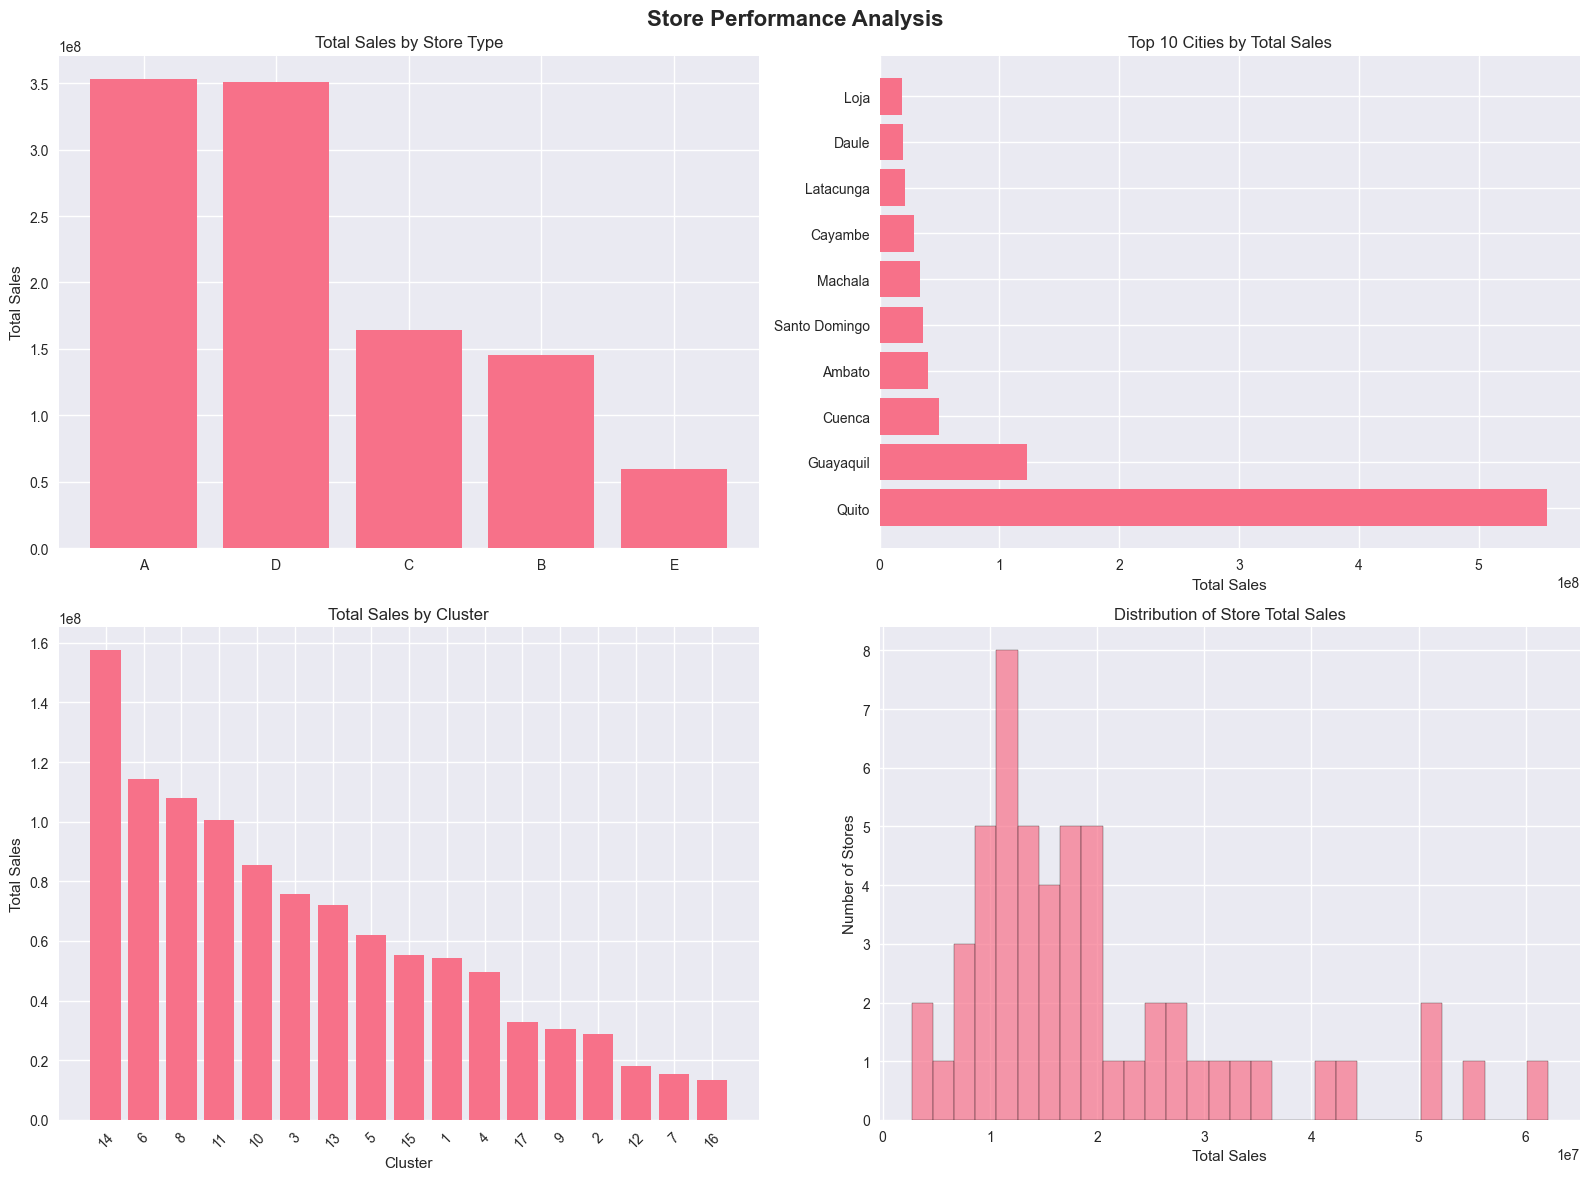


Top 5 performing stores:
    store_nbr   city type   total_sales
43         44  Quito    A  6.208755e+07
44         45  Quito    A  5.449801e+07
46         47  Quito    A  5.094831e+07
2           3  Quito    D  5.048191e+07
48         49  Quito    A  4.342010e+07

Bottom 5 performing stores:
    store_nbr       city type   total_sales
51         52      Manta    A  2.696170e+06
21         22       Puyo    C  4.090202e+06
31         32  Guayaquil    C  5.951796e+06
29         30  Guayaquil    C  7.382074e+06
34         35     Playas    C  7.676679e+06


In [13]:
# Store performance analysis
store_performance = sales_with_stores.groupby(['store_nbr', 'city', 'state', 'type', 'cluster'])['sales'].agg([
    'sum', 'mean', 'std', 'count'
]).reset_index()
store_performance.columns = ['store_nbr', 'city', 'state', 'type', 'cluster', 'total_sales', 'avg_sales', 'std_sales', 'num_records']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Store Performance Analysis', fontsize=16, fontweight='bold')

# Sales by store type
type_sales = store_performance.groupby('type')['total_sales'].sum().sort_values(ascending=False)
axes[0,0].bar(type_sales.index, type_sales.values)
axes[0,0].set_title('Total Sales by Store Type')
axes[0,0].set_ylabel('Total Sales')

# Top 10 cities by sales
city_sales = store_performance.groupby('city')['total_sales'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(range(len(city_sales)), city_sales.values)
axes[0,1].set_yticks(range(len(city_sales)))
axes[0,1].set_yticklabels(city_sales.index)
axes[0,1].set_title('Top 10 Cities by Total Sales')
axes[0,1].set_xlabel('Total Sales')

# Sales distribution by cluster
cluster_sales = store_performance.groupby('cluster')['total_sales'].sum().sort_values(ascending=False)
axes[1,0].bar(cluster_sales.index.astype(str), cluster_sales.values)
axes[1,0].set_title('Total Sales by Cluster')
axes[1,0].set_ylabel('Total Sales')
axes[1,0].set_xlabel('Cluster')
axes[1,0].tick_params(axis='x', rotation=45)

# Store performance distribution
axes[1,1].hist(store_performance['total_sales'], bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Store Total Sales')
axes[1,1].set_xlabel('Total Sales')
axes[1,1].set_ylabel('Number of Stores')

plt.tight_layout()
plt.show()

# Print top and bottom performing stores
print("\nTop 5 performing stores:")
top_stores = store_performance.nlargest(5, 'total_sales')[['store_nbr', 'city', 'type', 'total_sales']]
print(top_stores)

print("\nBottom 5 performing stores:")
bottom_stores = store_performance.nsmallest(5, 'total_sales')[['store_nbr', 'city', 'type', 'total_sales']]
print(bottom_stores)

## 5. Product Family Analysis

In [14]:
# Product family analysis
print("=== PRODUCT FAMILY ANALYSIS ===")
print(f"Total number of product families: {sales_df['family'].nunique()}")
print(f"Product families: {sorted(sales_df['family'].unique())}")

# Family performance
family_performance = sales_df.groupby('family')['sales'].agg([
    'sum', 'mean', 'std', 'count', 'median'
]).reset_index()
family_performance.columns = ['family', 'total_sales', 'avg_sales', 'std_sales', 'num_records', 'median_sales']
family_performance = family_performance.sort_values('total_sales', ascending=False)

print("\nTop 10 product families by total sales:")
print(family_performance.head(10)[['family', 'total_sales', 'avg_sales']])

=== PRODUCT FAMILY ANALYSIS ===
Total number of product families: 33
Product families: ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']

Top 10 product families by total sales:
           family   total_sales    avg_sales
12      GROCERY I  3.434627e+08  3776.972100
3       BEVERAGES  2.169545e+08  2385.793151
30        PRODUCE  1.227047e+08  1349.352123
7        CLEANING  9.752129e+07  1072.416744
8           DAIRY  6.448771e+07   709.154889
5    BREAD/BAKERY  4.213395e+07   463.336254
28        POULTRY  3.187600e+07   350.532292
24          MEATS  3.108

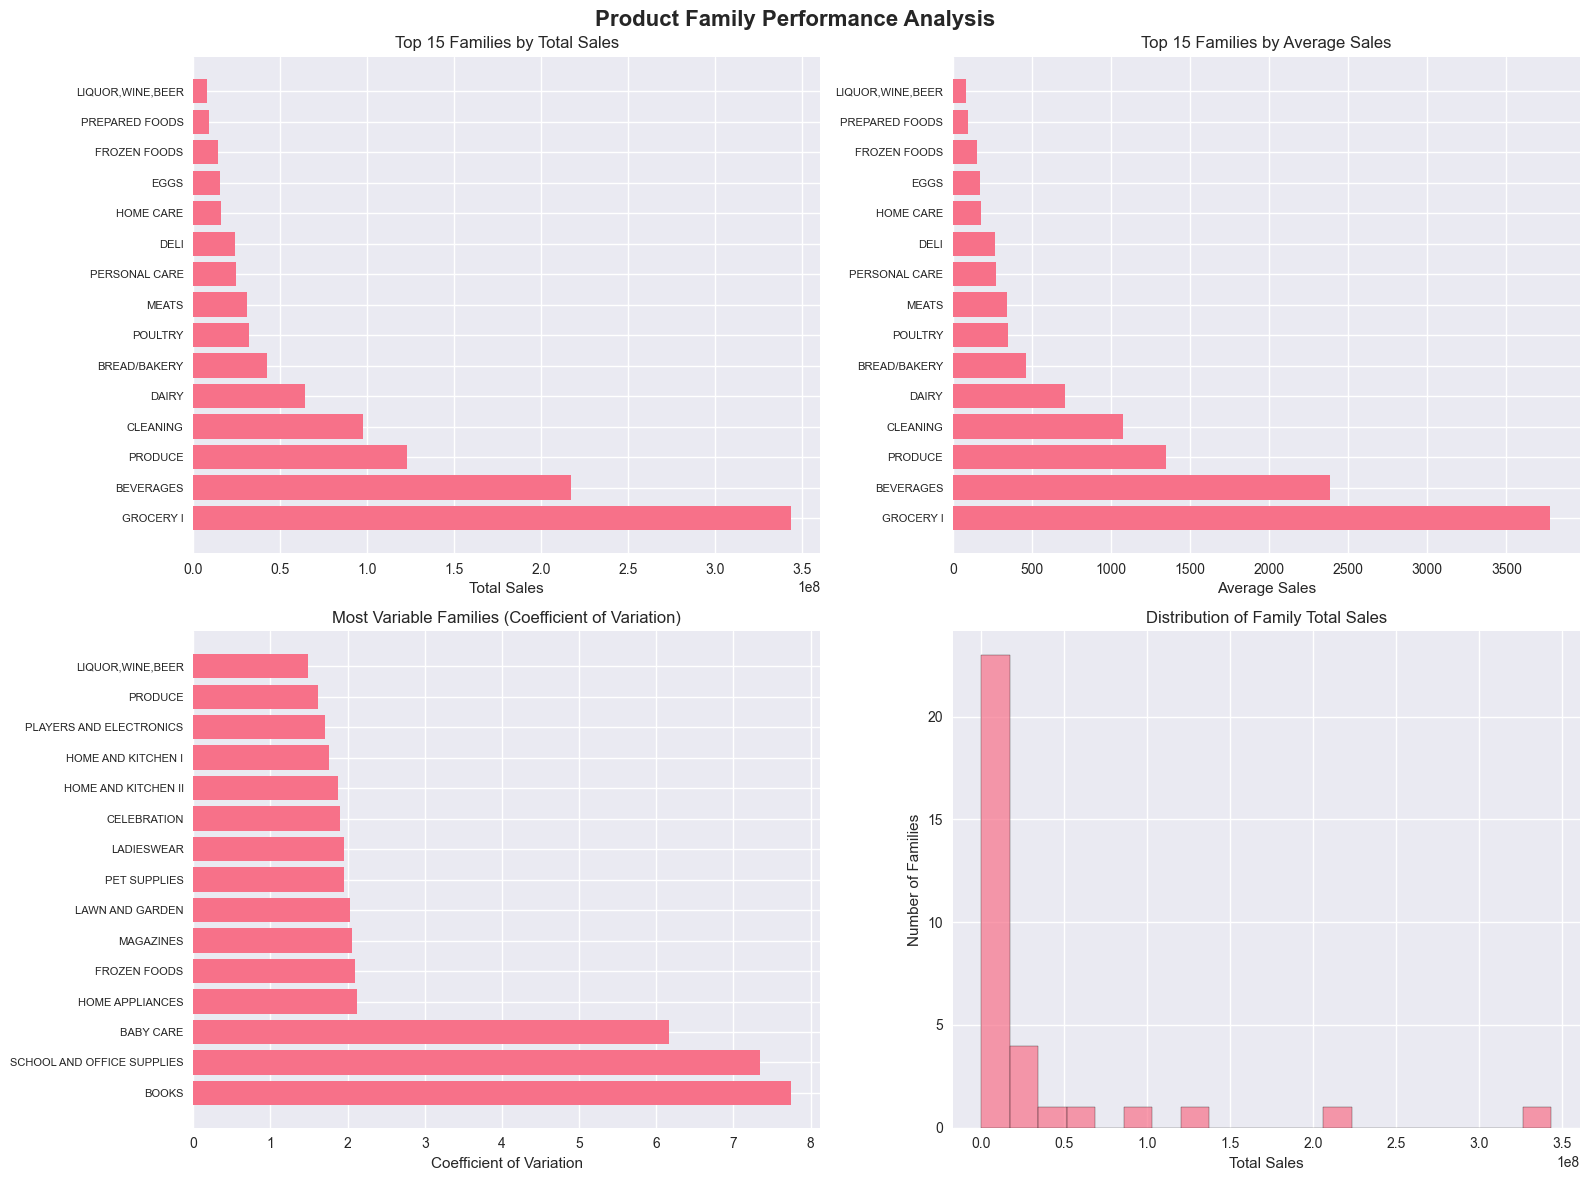

In [15]:
# Visualize family performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Product Family Performance Analysis', fontsize=16, fontweight='bold')

# Top families by total sales
top_families = family_performance.head(15)
axes[0,0].barh(range(len(top_families)), top_families['total_sales'])
axes[0,0].set_yticks(range(len(top_families)))
axes[0,0].set_yticklabels(top_families['family'], fontsize=8)
axes[0,0].set_title('Top 15 Families by Total Sales')
axes[0,0].set_xlabel('Total Sales')

# Average sales per transaction
axes[0,1].barh(range(len(top_families)), top_families['avg_sales'])
axes[0,1].set_yticks(range(len(top_families)))
axes[0,1].set_yticklabels(top_families['family'], fontsize=8)
axes[0,1].set_title('Top 15 Families by Average Sales')
axes[0,1].set_xlabel('Average Sales')

# Sales variability (coefficient of variation)
family_performance['cv'] = family_performance['std_sales'] / family_performance['avg_sales']
top_cv = family_performance.nlargest(15, 'cv')
axes[1,0].barh(range(len(top_cv)), top_cv['cv'])
axes[1,0].set_yticks(range(len(top_cv)))
axes[1,0].set_yticklabels(top_cv['family'], fontsize=8)
axes[1,0].set_title('Most Variable Families (Coefficient of Variation)')
axes[1,0].set_xlabel('Coefficient of Variation')

# Distribution of family total sales
axes[1,1].hist(family_performance['total_sales'], bins=20, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Family Total Sales')
axes[1,1].set_xlabel('Total Sales')
axes[1,1].set_ylabel('Number of Families')

plt.tight_layout()
plt.show()

## 6. Seasonal and Cyclical Patterns

In [16]:
# Add time-based features for seasonal analysis
sales_temporal = sales_df.copy()
sales_temporal['year'] = sales_temporal['date'].dt.year
sales_temporal['month'] = sales_temporal['date'].dt.month
sales_temporal['day_of_week'] = sales_temporal['date'].dt.dayofweek
sales_temporal['day_of_year'] = sales_temporal['date'].dt.dayofyear
sales_temporal['week_of_year'] = sales_temporal['date'].dt.isocalendar().week

# Day of week mapping
dow_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
sales_temporal['day_name'] = sales_temporal['day_of_week'].map(dow_mapping)

# Month mapping
month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
sales_temporal['month_name'] = sales_temporal['month'].map(month_mapping)

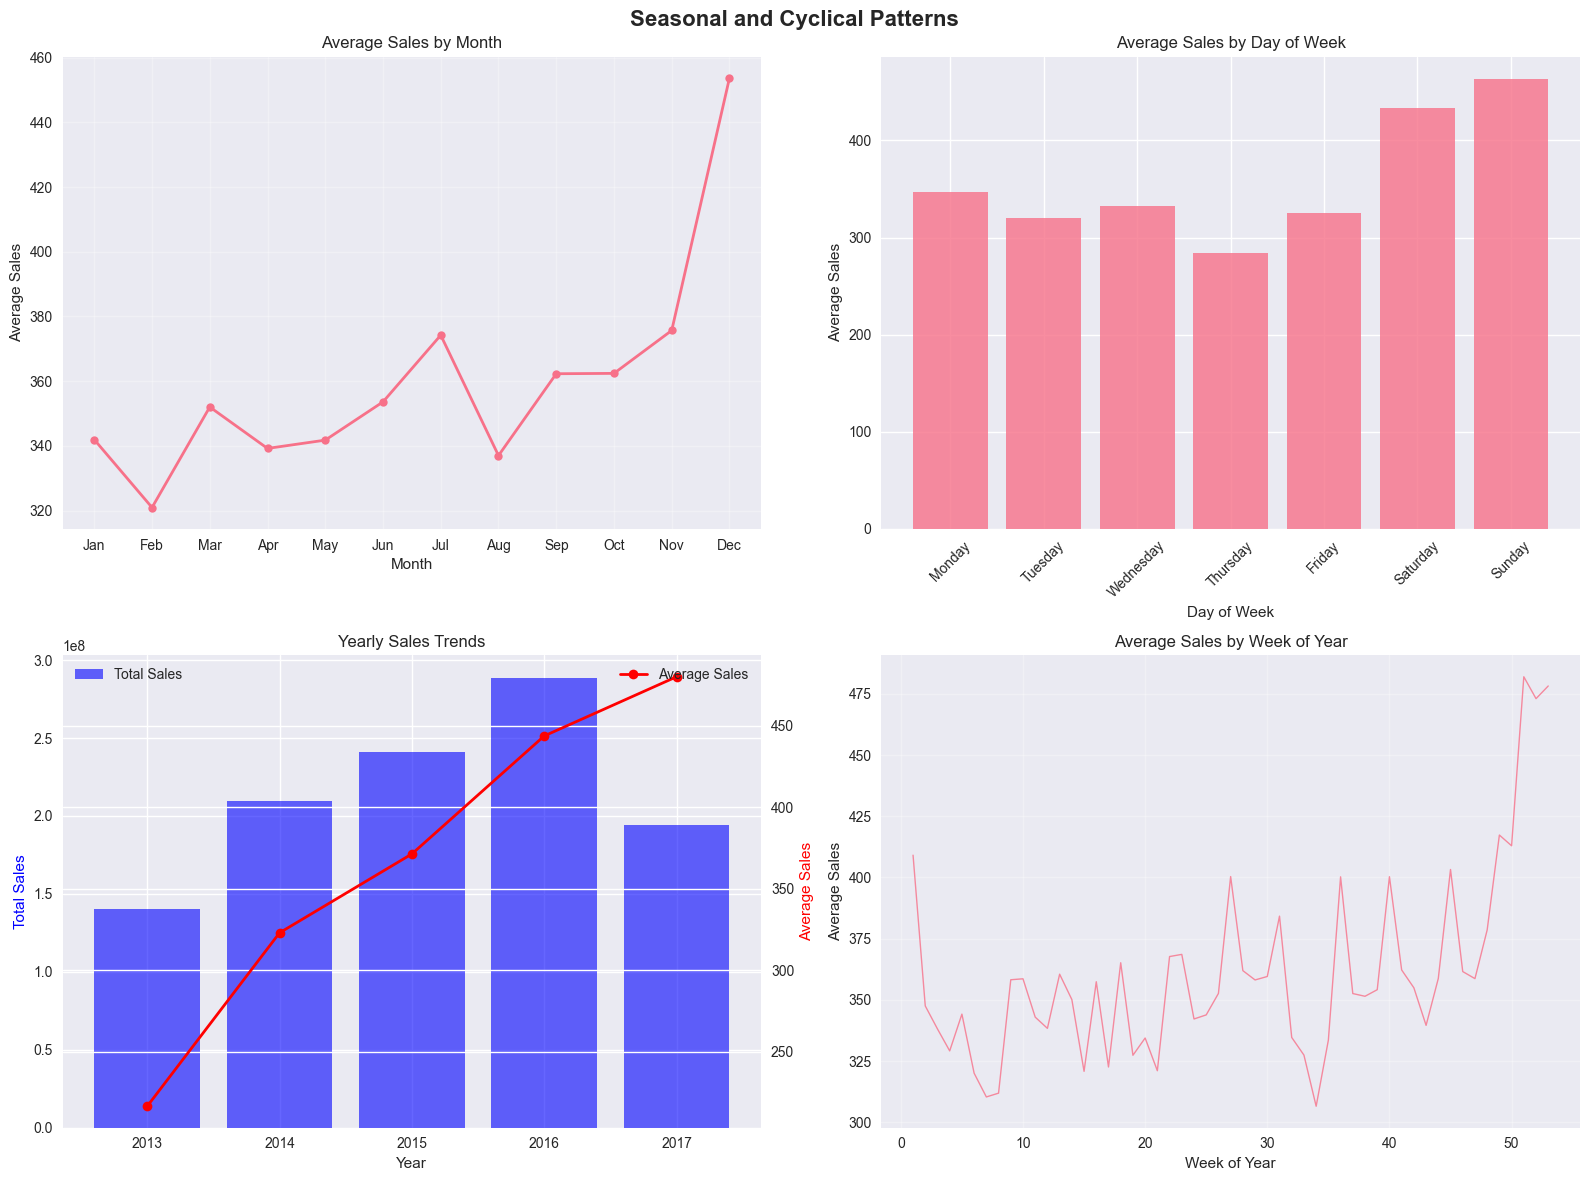


=== SEASONAL INSIGHTS ===
Highest sales month: Dec (avg: 453.74)
Lowest sales month: Feb (avg: 320.93)
Best day of week: Sunday (avg: 463.09)
Worst day of week: Thursday (avg: 283.54)
Best performing year: 2016 (total: 288,654,522.95)


In [17]:
# Seasonal patterns analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seasonal and Cyclical Patterns', fontsize=16, fontweight='bold')

# Monthly patterns
monthly_pattern = sales_temporal.groupby('month')['sales'].mean()
axes[0,0].plot(monthly_pattern.index, monthly_pattern.values, marker='o', linewidth=2, markersize=6)
axes[0,0].set_title('Average Sales by Month')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Average Sales')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].set_xticklabels([month_mapping[i] for i in range(1, 13)])
axes[0,0].grid(True, alpha=0.3)

# Day of week patterns
dow_pattern = sales_temporal.groupby('day_of_week')['sales'].mean()
axes[0,1].bar(range(7), dow_pattern.values, alpha=0.8)
axes[0,1].set_title('Average Sales by Day of Week')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Average Sales')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels([dow_mapping[i] for i in range(7)], rotation=45)

# Yearly trends
yearly_pattern = sales_temporal.groupby('year')['sales'].agg(['sum', 'mean'])
ax1 = axes[1,0]
ax2 = ax1.twinx()
ax1.bar(yearly_pattern.index, yearly_pattern['sum'], alpha=0.6, color='blue', label='Total Sales')
ax2.plot(yearly_pattern.index, yearly_pattern['mean'], color='red', marker='o', linewidth=2, label='Average Sales')
ax1.set_title('Yearly Sales Trends')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales', color='blue')
ax2.set_ylabel('Average Sales', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Weekly patterns throughout the year
weekly_pattern = sales_temporal.groupby('week_of_year')['sales'].mean()
axes[1,1].plot(weekly_pattern.index, weekly_pattern.values, linewidth=1, alpha=0.8)
axes[1,1].set_title('Average Sales by Week of Year')
axes[1,1].set_xlabel('Week of Year')
axes[1,1].set_ylabel('Average Sales')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print insights
print("\n=== SEASONAL INSIGHTS ===")
print(f"Highest sales month: {month_mapping[monthly_pattern.idxmax()]} (avg: {monthly_pattern.max():.2f})")
print(f"Lowest sales month: {month_mapping[monthly_pattern.idxmin()]} (avg: {monthly_pattern.min():.2f})")
print(f"Best day of week: {dow_mapping[dow_pattern.idxmax()]} (avg: {dow_pattern.max():.2f})")
print(f"Worst day of week: {dow_mapping[dow_pattern.idxmin()]} (avg: {dow_pattern.min():.2f})")
print(f"Best performing year: {yearly_pattern['sum'].idxmax()} (total: {yearly_pattern['sum'].max():,.2f})")

## 7. Promotion Analysis

In [19]:
# Promotion impact analysis
print("=== PROMOTION ANALYSIS ===")

sales_df = sales_df.copy()
sales_df["promo_flag"] = (sales_df["onpromotion"] > 0)

promo_stats = (
    sales_df.groupby("promo_flag")["sales"]
    .agg(["count", "mean", "sum", "std"])
    .round(2)
)

# Remap propre et robuste (même si un groupe manque)
promo_stats = promo_stats.rename(index={False: "No Promotion", True: "On Promotion"})

print("Sales statistics by promotion status:")
print(promo_stats)

# Calculate promotion lift
avg_sales_no_promo = sales_df[sales_df['onpromotion'] == 0]['sales'].mean()
avg_sales_promo = sales_df[sales_df['onpromotion'] > 0]['sales'].mean()
promotion_lift = ((avg_sales_promo - avg_sales_no_promo) / avg_sales_no_promo) * 100

print(f"\nPromotion Impact:")
print(f"Average sales without promotion: {avg_sales_no_promo:.2f}")
print(f"Average sales with promotion: {avg_sales_promo:.2f}")
print(f"Promotion lift: {promotion_lift:.1f}%")

# Promotion frequency
total_records = len(sales_df)
promo_records = len(sales_df[sales_df['onpromotion'] > 0])
promo_frequency = (promo_records / total_records) * 100
print(f"\nPromotion frequency: {promo_frequency:.1f}% of all records")

=== PROMOTION ANALYSIS ===
Sales statistics by promotion status:
                count     mean           sum      std
promo_flag                                           
No Promotion  2389559   158.25  3.781398e+08   614.89
On Promotion   611329  1137.69  6.955052e+08  1928.59

Promotion Impact:
Average sales without promotion: 158.25
Average sales with promotion: 1137.69
Promotion lift: 618.9%

Promotion frequency: 20.4% of all records


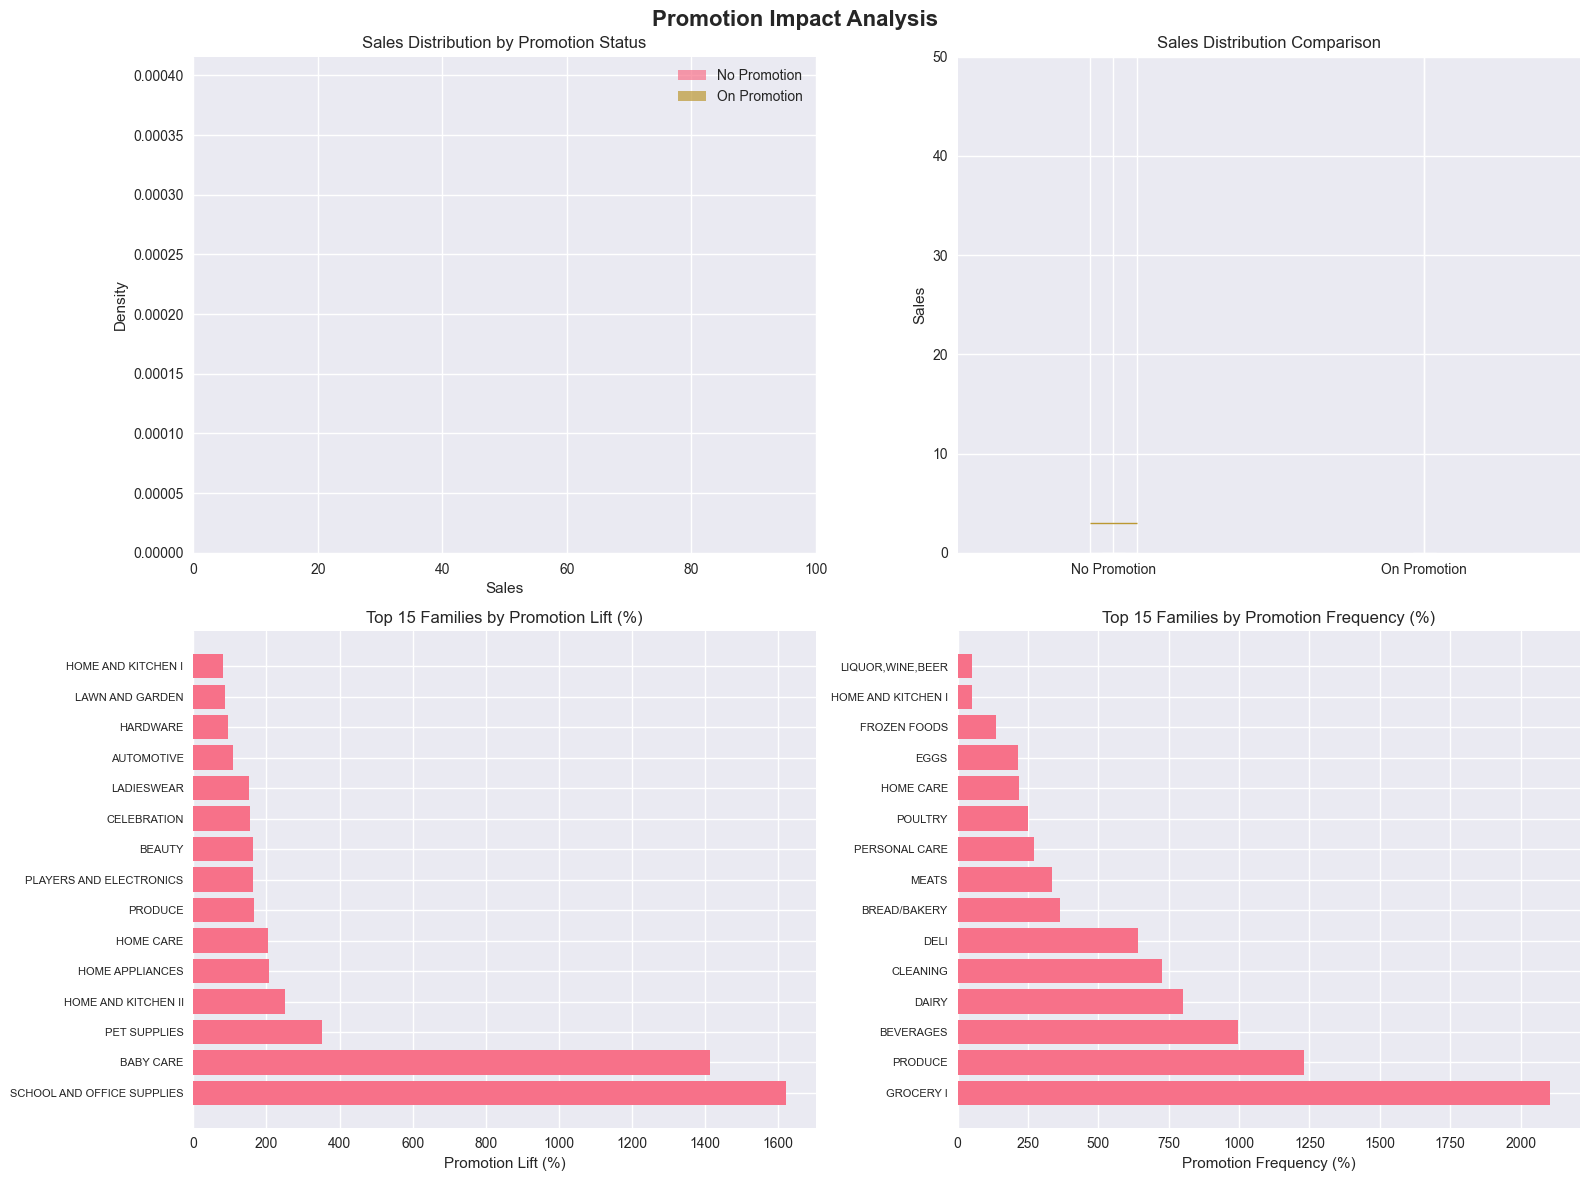

In [20]:
# Visualize promotion impact
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Promotion Impact Analysis', fontsize=16, fontweight='bold')

# Sales distribution by promotion status
sales_no_promo = sales_df[sales_df['onpromotion'] == 0]['sales']
sales_promo = sales_df[sales_df['onpromotion'] > 0]['sales']

axes[0,0].hist([sales_no_promo, sales_promo], bins=50, alpha=0.7, 
               label=['No Promotion', 'On Promotion'], density=True)
axes[0,0].set_title('Sales Distribution by Promotion Status')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()
axes[0,0].set_xlim(0, 100)  # Focus on main distribution

# Box plot comparison
promo_data = [sales_no_promo, sales_promo]
axes[0,1].boxplot(promo_data, labels=['No Promotion', 'On Promotion'])
axes[0,1].set_title('Sales Distribution Comparison')
axes[0,1].set_ylabel('Sales')
axes[0,1].set_ylim(0, 50)  # Focus on main distribution

# Promotion impact by family
family_promo_impact = sales_df.groupby(['family', 'onpromotion'])['sales'].mean().unstack(fill_value=0)
family_promo_impact['lift'] = ((family_promo_impact[1] - family_promo_impact[0]) / family_promo_impact[0]) * 100
family_promo_impact = family_promo_impact.sort_values('lift', ascending=False).head(15)

axes[1,0].barh(range(len(family_promo_impact)), family_promo_impact['lift'])
axes[1,0].set_yticks(range(len(family_promo_impact)))
axes[1,0].set_yticklabels(family_promo_impact.index, fontsize=8)
axes[1,0].set_title('Top 15 Families by Promotion Lift (%)')
axes[1,0].set_xlabel('Promotion Lift (%)')

# Promotion frequency by family
family_promo_freq = sales_df.groupby('family').agg({
    'onpromotion': ['sum', 'count']
}).round(2)
family_promo_freq.columns = ['promo_count', 'total_count']
family_promo_freq['promo_frequency'] = (family_promo_freq['promo_count'] / family_promo_freq['total_count']) * 100
family_promo_freq = family_promo_freq.sort_values('promo_frequency', ascending=False).head(15)

axes[1,1].barh(range(len(family_promo_freq)), family_promo_freq['promo_frequency'])
axes[1,1].set_yticks(range(len(family_promo_freq)))
axes[1,1].set_yticklabels(family_promo_freq.index, fontsize=8)
axes[1,1].set_title('Top 15 Families by Promotion Frequency (%)')
axes[1,1].set_xlabel('Promotion Frequency (%)')

plt.tight_layout()
plt.show()

## 8. External Factors Analysis

In [21]:
# Oil price analysis
print("=== OIL PRICE ANALYSIS ===")
print(f"Oil price data coverage: {oil_df['date'].min()} to {oil_df['date'].max()}")
print(f"Missing oil price values: {oil_df['dcoilwtico'].isnull().sum()} out of {len(oil_df)}")

# Fill missing oil prices for analysis
oil_clean = oil_df.copy()
oil_clean['dcoilwtico'] = oil_clean['dcoilwtico'].fillna(method='ffill').fillna(method='bfill')

print(f"Oil price range: ${oil_clean['dcoilwtico'].min():.2f} - ${oil_clean['dcoilwtico'].max():.2f}")
print(f"Average oil price: ${oil_clean['dcoilwtico'].mean():.2f}")

# Merge with daily sales for correlation analysis
daily_sales_oil = daily_sales.merge(oil_clean, on='date', how='left')
oil_sales_corr = daily_sales_oil[['sum', 'dcoilwtico']].corr().iloc[0,1]
print(f"\nCorrelation between oil prices and daily total sales: {oil_sales_corr:.3f}")

=== OIL PRICE ANALYSIS ===
Oil price data coverage: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Missing oil price values: 43 out of 1218
Oil price range: $26.19 - $110.62
Average oil price: $67.69

Correlation between oil prices and daily total sales: -0.690


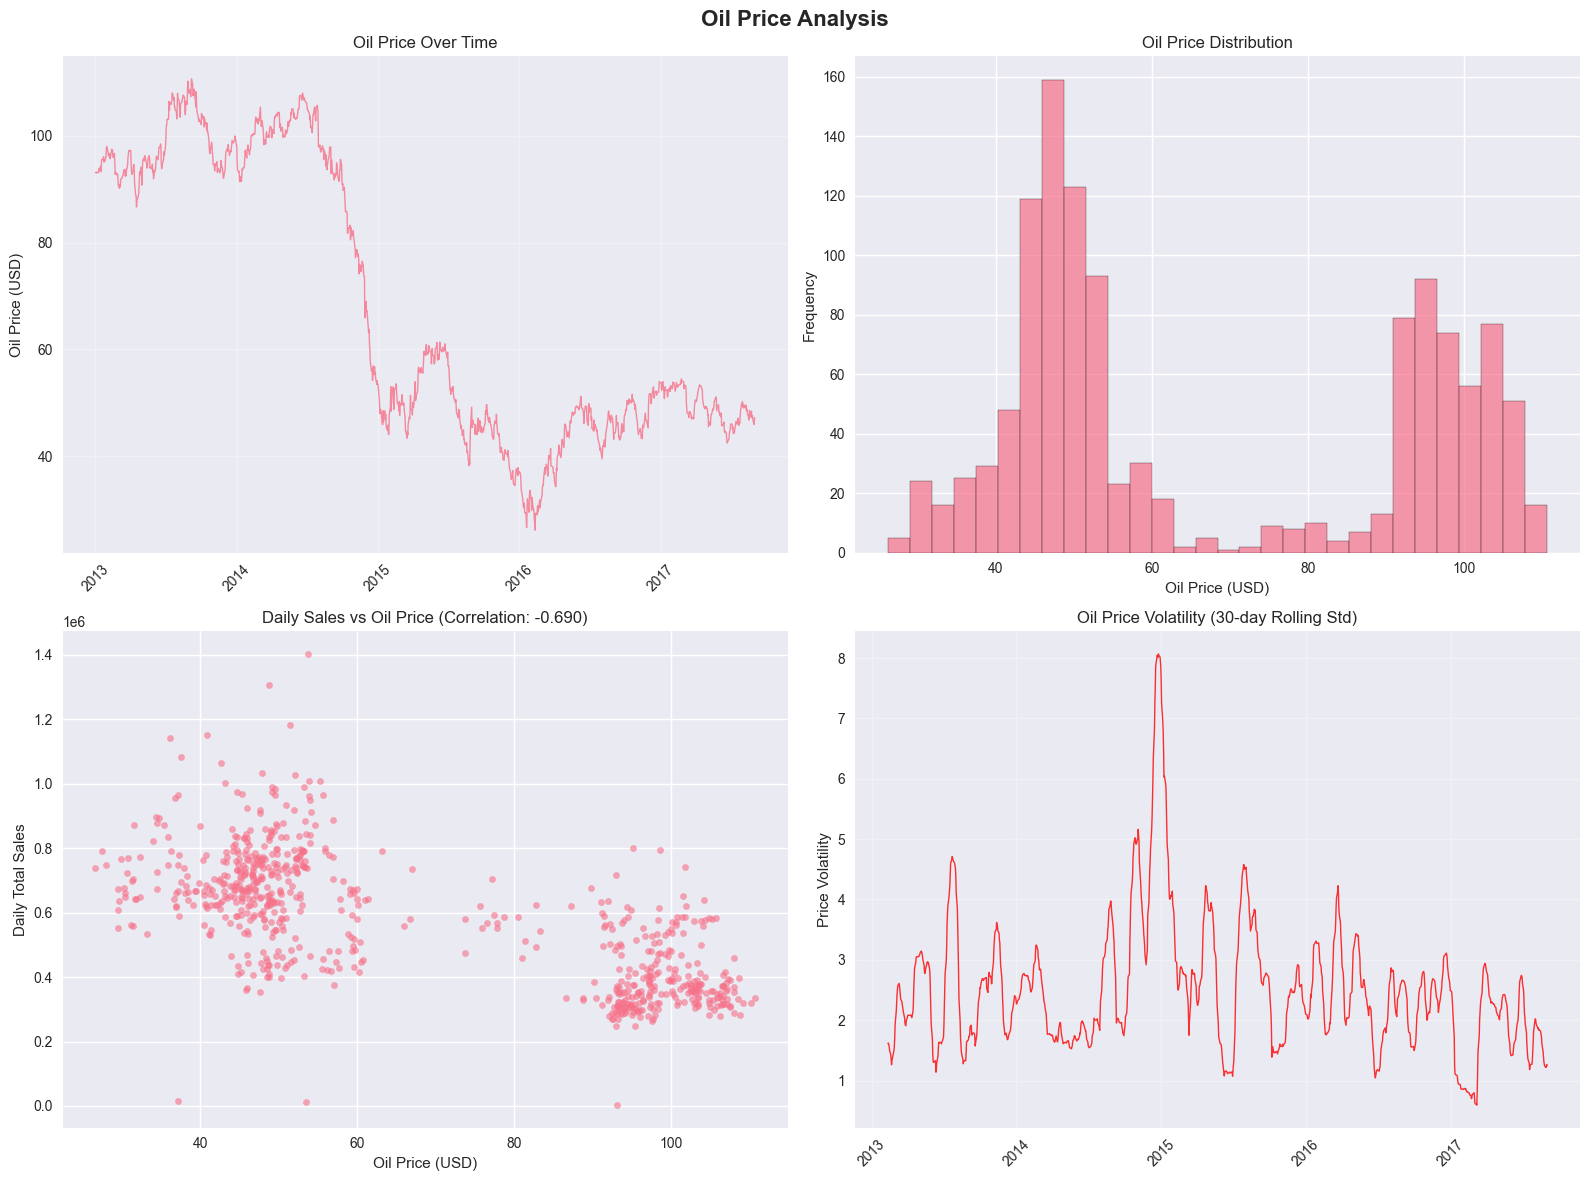

In [22]:
# Visualize oil price trends and relationship with sales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Oil Price Analysis', fontsize=16, fontweight='bold')

# Oil price over time
axes[0,0].plot(oil_clean['date'], oil_clean['dcoilwtico'], linewidth=1, alpha=0.8)
axes[0,0].set_title('Oil Price Over Time')
axes[0,0].set_ylabel('Oil Price (USD)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Oil price distribution
axes[0,1].hist(oil_clean['dcoilwtico'], bins=30, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Oil Price Distribution')
axes[0,1].set_xlabel('Oil Price (USD)')
axes[0,1].set_ylabel('Frequency')

# Sales vs Oil Price scatter plot
sample_data = daily_sales_oil.sample(n=min(1000, len(daily_sales_oil)))  # Sample for better visualization
axes[1,0].scatter(sample_data['dcoilwtico'], sample_data['sum'], alpha=0.6, s=20)
axes[1,0].set_title(f'Daily Sales vs Oil Price (Correlation: {oil_sales_corr:.3f})')
axes[1,0].set_xlabel('Oil Price (USD)')
axes[1,0].set_ylabel('Daily Total Sales')

# Oil price volatility (30-day rolling std)
oil_clean['oil_volatility'] = oil_clean['dcoilwtico'].rolling(window=30).std()
axes[1,1].plot(oil_clean['date'], oil_clean['oil_volatility'], linewidth=1, alpha=0.8, color='red')
axes[1,1].set_title('Oil Price Volatility (30-day Rolling Std)')
axes[1,1].set_ylabel('Price Volatility')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Holiday analysis
print("\n=== HOLIDAY ANALYSIS ===")
print(f"Total holiday events: {len(holidays_df)}")
print(f"Holiday types: {holidays_df['type'].value_counts().to_dict()}")
print(f"Holiday locales: {holidays_df['locale'].value_counts().to_dict()}")
print(f"Transferred holidays: {holidays_df['transferred'].value_counts().to_dict()}")

# Analyze holiday impact on sales
# Create a simple holiday indicator (National holidays only for simplicity)
national_holidays = holidays_df[holidays_df['locale'] == 'National']['date'].unique()
daily_sales['is_holiday'] = daily_sales['date'].isin(national_holidays)

holiday_impact = daily_sales.groupby('is_holiday')['sum'].agg(['mean', 'std', 'count'])
holiday_impact.index = ['Regular Day', 'National Holiday']
print("\nNational Holiday Impact on Sales:")
print(holiday_impact)

# Calculate holiday lift
regular_day_sales = daily_sales[~daily_sales['is_holiday']]['sum'].mean()
holiday_sales = daily_sales[daily_sales['is_holiday']]['sum'].mean()
holiday_lift = ((holiday_sales - regular_day_sales) / regular_day_sales) * 100
print(f"\nNational Holiday lift: {holiday_lift:.1f}%")


=== HOLIDAY ANALYSIS ===
Total holiday events: 350
Holiday types: {'Holiday': 221, 'Event': 56, 'Additional': 51, 'Transfer': 12, 'Bridge': 5, 'Work Day': 5}
Holiday locales: {'National': 174, 'Local': 152, 'Regional': 24}
Transferred holidays: {False: 338, True: 12}

National Holiday Impact on Sales:
                           mean            std  count
Regular Day       628494.211374  227005.418964   1541
National Holiday  735212.394940  286172.032538    143

National Holiday lift: 17.0%


## 9. Sales Distribution and Outlier Analysis

In [24]:
# Sales distribution analysis
print("=== SALES DISTRIBUTION ANALYSIS ===")
print(f"Total records: {len(sales_df):,}")
print(f"Zero sales records: {(sales_df['sales'] == 0).sum():,} ({(sales_df['sales'] == 0).mean()*100:.1f}%)")
print(f"Negative sales records: {(sales_df['sales'] < 0).sum():,}")

# Basic statistics
print("\nSales statistics:")
print(sales_df['sales'].describe())

# Identify outliers using IQR method
Q1 = sales_df['sales'].quantile(0.25)
Q3 = sales_df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = sales_df[(sales_df['sales'] < lower_bound) | (sales_df['sales'] > upper_bound)]
print(f"\nOutliers (IQR method): {len(outliers):,} ({len(outliers)/len(sales_df)*100:.1f}%)")
print(f"Outlier range: < {lower_bound:.2f} or > {upper_bound:.2f}")

# Extreme values
print(f"\nTop 10 highest sales:")
top_sales = sales_df.nlargest(10, 'sales')[['date', 'store_nbr', 'family', 'sales', 'onpromotion']]
print(top_sales)

=== SALES DISTRIBUTION ANALYSIS ===
Total records: 3,000,888
Zero sales records: 939,130 (31.3%)
Negative sales records: 0

Sales statistics:
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

Outliers (IQR method): 447,105 (14.9%)
Outlier range: < -293.77 or > 489.62

Top 10 highest sales:
              date  store_nbr     family       sales  onpromotion
2163723 2016-05-02          2  GROCERY I  124717.000           59
2445984 2016-10-07         39      MEATS   89576.360            0
2144154 2016-04-21         20  GROCERY I   87438.516           53
2139699 2016-04-18         45  GROCERY I   76090.000           38
2153031 2016-04-26          2  GROCERY I   63434.000           30
2145045 2016-04-21         45  GROCERY I   53874.000           44
562596  2013-11-12         44  GROCERY I   46271.000            0
1257246 2014-12-08        

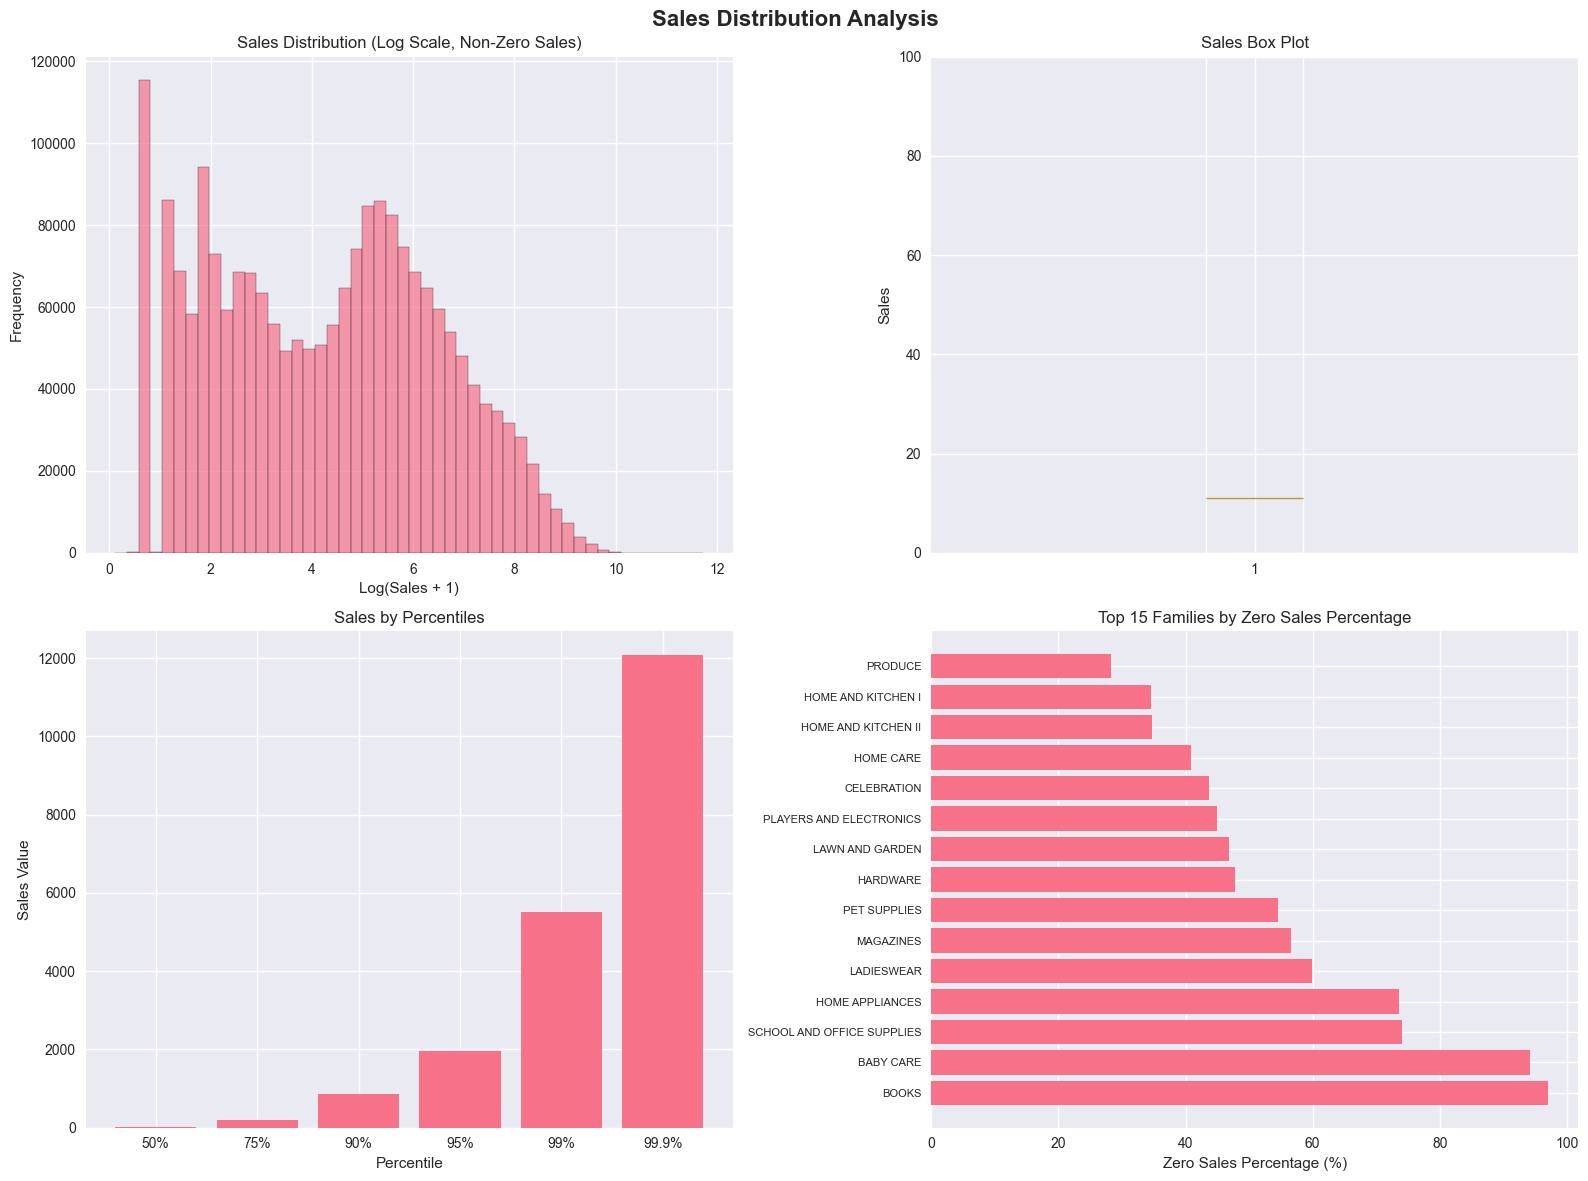

In [25]:
# Visualize sales distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Distribution Analysis', fontsize=16, fontweight='bold')

# Overall sales distribution (log scale for better visualization)
non_zero_sales = sales_df[sales_df['sales'] > 0]['sales']
axes[0,0].hist(np.log1p(non_zero_sales), bins=50, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Sales Distribution (Log Scale, Non-Zero Sales)')
axes[0,0].set_xlabel('Log(Sales + 1)')
axes[0,0].set_ylabel('Frequency')

# Box plot of sales (limited range for visibility)
axes[0,1].boxplot(sales_df['sales'])
axes[0,1].set_title('Sales Box Plot')
axes[0,1].set_ylabel('Sales')
axes[0,1].set_ylim(0, 100)  # Focus on main distribution

# Sales by percentiles
percentiles = [50, 75, 90, 95, 99, 99.9]
percentile_values = [sales_df['sales'].quantile(p/100) for p in percentiles]
axes[1,0].bar(range(len(percentiles)), percentile_values)
axes[1,0].set_title('Sales by Percentiles')
axes[1,0].set_xlabel('Percentile')
axes[1,0].set_ylabel('Sales Value')
axes[1,0].set_xticks(range(len(percentiles)))
axes[1,0].set_xticklabels([f'{p}%' for p in percentiles])

# Zero sales analysis by family
zero_sales_by_family = sales_df.groupby('family').agg({
    'sales': ['count', lambda x: (x == 0).sum()]
})
zero_sales_by_family.columns = ['total_records', 'zero_sales']
zero_sales_by_family['zero_pct'] = (zero_sales_by_family['zero_sales'] / zero_sales_by_family['total_records']) * 100
zero_sales_by_family = zero_sales_by_family.sort_values('zero_pct', ascending=False).head(15)

axes[1,1].barh(range(len(zero_sales_by_family)), zero_sales_by_family['zero_pct'])
axes[1,1].set_yticks(range(len(zero_sales_by_family)))
axes[1,1].set_yticklabels(zero_sales_by_family.index, fontsize=8)
axes[1,1].set_title('Top 15 Families by Zero Sales Percentage')
axes[1,1].set_xlabel('Zero Sales Percentage (%)')

plt.tight_layout()
plt.show()

## 10. Correlation Analysis

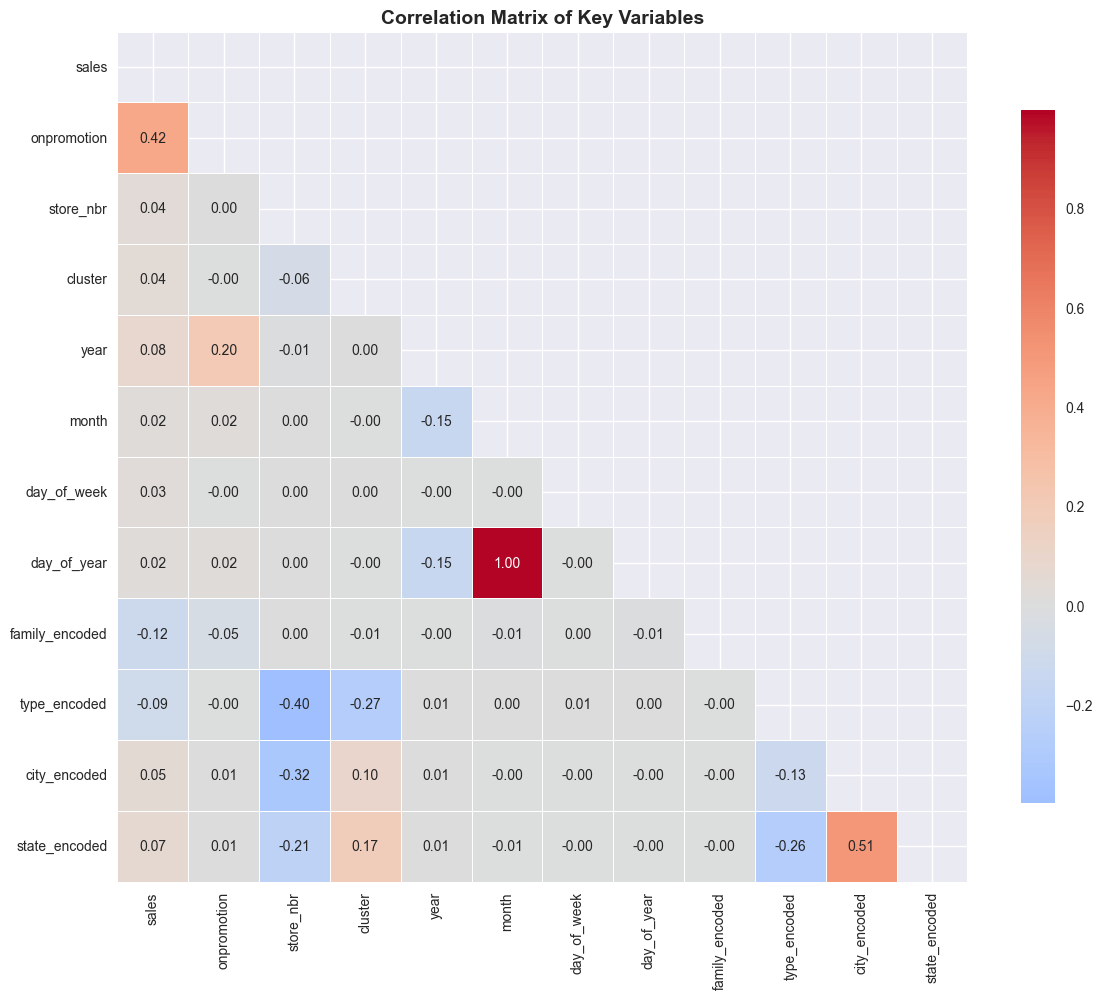


Strongest correlations with sales:
onpromotion: 0.420
family_encoded: -0.115
type_encoded: -0.093
year: 0.083
state_encoded: 0.068
city_encoded: 0.050
cluster: 0.038
store_nbr: 0.038
day_of_week: 0.028
month: 0.021
day_of_year: 0.019


In [26]:
# Create a dataset for correlation analysis
# Sample data for performance (correlation on full dataset can be slow)
sample_size = min(50000, len(sales_df))
sales_sample = sales_df.sample(n=sample_size, random_state=42)

# Add temporal features
sales_sample = sales_sample.copy()
sales_sample['year'] = sales_sample['date'].dt.year
sales_sample['month'] = sales_sample['date'].dt.month
sales_sample['day_of_week'] = sales_sample['date'].dt.dayofweek
sales_sample['day_of_year'] = sales_sample['date'].dt.dayofyear

# Merge with store info
sales_sample = sales_sample.merge(stores_df, on='store_nbr', how='left')

# Encode categorical variables for correlation
from sklearn.preprocessing import LabelEncoder
le_family = LabelEncoder()
le_type = LabelEncoder()
le_city = LabelEncoder()
le_state = LabelEncoder()

sales_sample['family_encoded'] = le_family.fit_transform(sales_sample['family'])
sales_sample['type_encoded'] = le_type.fit_transform(sales_sample['type'])
sales_sample['city_encoded'] = le_city.fit_transform(sales_sample['city'])
sales_sample['state_encoded'] = le_state.fit_transform(sales_sample['state'])

# Select numerical columns for correlation
corr_columns = ['sales', 'onpromotion', 'store_nbr', 'cluster', 'year', 'month', 
                'day_of_week', 'day_of_year', 'family_encoded', 'type_encoded', 
                'city_encoded', 'state_encoded']

correlation_matrix = sales_sample[corr_columns].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
plt.title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations with sales
sales_correlations = correlation_matrix['sales'].abs().sort_values(ascending=False)
print("\nStrongest correlations with sales:")
for var, corr in sales_correlations.items():
    if var != 'sales':
        print(f"{var}: {correlation_matrix['sales'][var]:.3f}")

## 11. Key Insights and Recommendations

In [27]:
print("\n" + "="*60)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR FORECASTING")
print("="*60)

print("\n1. DATA CHARACTERISTICS:")
print(f"   • Dataset spans {sales_df['date'].nunique()} days from {sales_df['date'].min().date()} to {sales_df['date'].max().date()}")
print(f"   • {sales_df['store_nbr'].nunique()} stores across {stores_df['city'].nunique()} cities")
print(f"   • {sales_df['family'].nunique()} product families")
print(f"   • {(sales_df['sales'] == 0).mean()*100:.1f}% of records have zero sales (store closures/stockouts)")

print("\n2. SEASONAL PATTERNS:")
best_month = month_mapping[monthly_pattern.idxmax()]
worst_month = month_mapping[monthly_pattern.idxmin()]
best_dow = dow_mapping[dow_pattern.idxmax()]
worst_dow = dow_mapping[dow_pattern.idxmin()]
print(f"   • Strong monthly seasonality: {best_month} is peak ({monthly_pattern.max():.1f}), {worst_month} is lowest ({monthly_pattern.min():.1f})")
print(f"   • Weekly patterns: {best_dow} has highest sales, {worst_dow} has lowest")
print(f"   • Year-over-year growth trend visible in the data")

print("\n3. PROMOTION IMPACT:")
print(f"   • Promotions occur in {promo_frequency:.1f}% of all records")
print(f"   • Average promotion lift: {promotion_lift:.1f}%")
print(f"   • Significant variation in promotion effectiveness across product families")

print("\n4. EXTERNAL FACTORS:")
print(f"   • Oil price correlation with sales: {oil_sales_corr:.3f}")
print(f"   • National holidays show {holiday_lift:.1f}% impact on sales")
print(f"   • Oil price volatility may affect consumer behavior")

print("\n5. FORECASTING RECOMMENDATIONS:")
print("   • Handle zero sales explicitly (store closures vs. stockouts)")
print("   • Include strong seasonal components (monthly, weekly, yearly)")
print("   • Model promotion effects with family-specific parameters")
print("   • Consider external factors (oil prices, holidays) as features")
print("   • Use hierarchical modeling (store-family level with aggregation)")
print("   • Account for outliers and extreme sales events")
print("   • Implement proper cross-validation respecting temporal order")

print("\n6. DATA PREPROCESSING NEEDS:")
print("   • Handle missing oil price data (forward/backward fill)")
print("   • Create lag features for time series modeling")
print("   • Engineer cyclical features (sin/cos transformations)")
print("   • Normalize/scale features appropriately")
print("   • Create store/family embeddings for categorical variables")

print("\n" + "="*60)
print("EDA COMPLETE - Ready for Feature Engineering and Modeling")
print("="*60)


KEY INSIGHTS AND RECOMMENDATIONS FOR FORECASTING

1. DATA CHARACTERISTICS:
   • Dataset spans 1684 days from 2013-01-01 to 2017-08-15
   • 54 stores across 22 cities
   • 33 product families
   • 31.3% of records have zero sales (store closures/stockouts)

2. SEASONAL PATTERNS:
   • Strong monthly seasonality: Dec is peak (453.7), Feb is lowest (320.9)
   • Weekly patterns: Sunday has highest sales, Thursday has lowest
   • Year-over-year growth trend visible in the data

3. PROMOTION IMPACT:
   • Promotions occur in 20.4% of all records
   • Average promotion lift: 618.9%
   • Significant variation in promotion effectiveness across product families

4. EXTERNAL FACTORS:
   • Oil price correlation with sales: -0.690
   • National holidays show 17.0% impact on sales
   • Oil price volatility may affect consumer behavior

5. FORECASTING RECOMMENDATIONS:
   • Handle zero sales explicitly (store closures vs. stockouts)
   • Include strong seasonal components (monthly, weekly, yearly)
   •

## Summary

This comprehensive EDA has revealed key patterns and characteristics of the store sales dataset:

- **Strong seasonal patterns** with clear monthly and weekly cycles
- **Significant promotion effects** varying by product family
- **External factor influences** from oil prices and holidays
- **Data quality considerations** including zero sales and outliers
- **Hierarchical structure** across stores, cities, and product families

These insights will guide our feature engineering and model development approach for accurate sales forecasting.